In [ ]:
#https://www.kaggle.com/datasets/arushchillar/disneyland-reviews/data
import json
import tkinter as tk
from tkinter import filedialog
import base64
import mimetypes
import os
from urllib.parse import quote_plus
import pandas as pd

In [ ]:
data = pd.read_csv('DisneylandReviews.csv', encoding='latin1')
data['Review_Text'].head(1)

,Review_Text
0,If you've ever been to Disneyland anywhere you...


#Rating comments

In [ ]:
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [ ]:
test_message = data['Review_Text'][0]

In [ ]:
test_message

"If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when you walk into main street! It has a very familiar feel. One of the rides  its a Small World  is absolutely fabulous and worth doing. The day we visited was fairly hot and relatively busy but the queues moved fairly well. "

In [ ]:
comment = test_message
form = '{"mood": com1, "negative": com2, "positive": com3, "short": com4, "rate": com5}'
prompt_1 = f'''
Your task is to describe the comment using the template: {comment}.
You must respond with a "positive" or "negative" (quotation marks are required) comment, just one word. This word is further used as com1.
You must provide a list of non-fictitious words in the format: ["word1", "word2", ..., "last_word"] (quotation marks are required), if there are no words, then []. This list is further used as com2.
You should give a list of positive words in the format: ["word1", "word2", ..., "last_word"] (quotation marks are required), if there are no words, then []. This list is further used as com3.
You should give a summary of the commentary. The summary is further used as com4.
You have to give a score from 1 to 5. Just a number.
The correct response should be in the format: {form}"'
'''


In [ ]:
import requests

with open("apitoken.txt", "r") as file:
    token = file.read().strip()

response = requests.post(
    'https://bothub.chat/api/v2/openai/v1/chat/completions',
    headers={
        'Authorization': f'Bearer {token}',
        'Content-Type': 'application/json',
    },
    json={
        'model': 'gpt-4.1-mini',
        'messages': [
            {'role': 'user', 'content': prompt_1}
        ],
        'max_tokens': 1000,
    }
)

result = response.json()
print(result)

{'id': 'gen-1765871552-Enxi7cni1Mzz5tTROImM', 'provider': 'OpenAI', 'model': 'openai/gpt-4.1-mini', 'object': 'chat.completion', 'created': 1765871552, 'choices': [{'logprobs': None, 'finish_reason': 'stop', 'native_finish_reason': 'completed', 'index': 0, 'message': {'role': 'assistant', 'content': '{"mood": "positive", "negative": [], "positive": ["fabulous", "worth", "fairly well", "familiar", "similar"], "short": "Disneyland Hong Kong feels familiar and enjoyable, with a fabulous ride and manageable queues even on a busy day.", "rate": 4}', 'refusal': None, 'reasoning': None}}], 'usage': {'prompt_tokens': 293, 'completion_tokens': 66, 'total_tokens': 359, 'cost': 0.0002228, 'is_byok': False, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0, 'video_tokens': 0}, 'cost_details': {'upstream_inference_cost': None, 'upstream_inference_prompt_cost': 0.0001172, 'upstream_inference_completions_cost': 0.0001056}, 'completion_tokens_details': {'reasoning_tokens': 0, 'image_toke

In [ ]:
result['choices'][0]['message']['content']

'{"mood": "positive", "negative": [], "positive": ["fabulous", "worth", "fairly well", "familiar", "similar"], "short": "Disneyland Hong Kong feels familiar and enjoyable, with a fabulous ride and manageable queues even on a busy day.", "rate": 4}'

In [ ]:
data_dict = json.loads(result['choices'][0]['message']['content'])

In [ ]:
num_of_val = 4 #how many values do we take from the dataset from the beginning
data_for_test = data.head(num_of_val)
data_for_test

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong


In [ ]:
list_of_ans = list()
form = '{"mood": com1, "negative": com2, "positive": com3, "short": com4, "rate": com5}'

for i in range(num_of_val):
    comment = data_for_test['Review_Text'][i]
    print(comment)
    prompt_1 = f'''
    Your task is to describe the comment using the template: {comment}.
    You must respond with a "positive" or "negative" (quotation marks are required) comment, just one word. This word is further used as com1.
    You must provide a list of non-fictitious words in the format: ["word1", "word2", ..., "last_word"] (quotation marks are required), if there are no words, then []. This list is further used as com2.
    You should give a list of positive words in the format: ["word1", "word2", ..., "last_word"] (quotation marks are required), if there are no words, then []. This list is further used as com3.
    You should give a summary of the commentary. The summary is further used as com4.
    You have to give a score from 1 to 5. Just a number.
    The correct response should be in the format: {form}"'
    '''
    response = requests.post(
    'https://bothub.chat/api/v2/openai/v1/chat/completions',
    headers={
        'Authorization': f'Bearer {token}',
        'Content-Type': 'application/json',
    },
    json={
        'model': 'gpt-4.1-mini',
        'messages': [
            {'role': 'user', 'content': prompt_1}
        ],
        'max_tokens': 1000,
    }
    )
    result = response.json()
    list_of_ans.append(json.loads(result['choices'][0]['message']['content']))

If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when you walk into main street! It has a very familiar feel. One of the rides  its a Small World  is absolutely fabulous and worth doing. The day we visited was fairly hot and relatively busy but the queues moved fairly well. 
Its been a while since d last time we visit HK Disneyland .. Yet, this time we only stay in Tomorrowland .. AKA Marvel land!Now they have Iron Man Experience n d Newly open Ant Man n d Wasp!!Ironman .. Great feature n so Exciting, especially d whole scenery of HK (HK central area to Kowloon)!Antman .. Changed by previous Buzz lightyear! More or less d same, but I'm expecting to have something most!!However, my boys like it!!Space Mountain .. Turns into Star Wars!! This 1 is Great!!!For cast members (staffs) .. Felt bit MINUS point from before!!! Just dun feel like its a Disney brand!! Seems more local like Ocean Park or even worst!!They got no SMILING face, but 

In [ ]:
list_of_ans

[{'mood': 'positive',
  'negative': [],
  'positive': ['fabulous', 'worth', 'familiar', 'fairly well'],
  'short': 'The Disneyland Hong Kong experience is enjoyable with a familiar layout, a fantastic ride, and manageable queues despite the heat and busyness.',
  'rate': 4},
 {'mood': 'negative',
  'negative': ['MINUS', 'worst', 'local'],
  'positive': ['Exciting',
   'Great',
   'Good',
   'attractive',
   'Smiling',
   'Happiest',
   'Star Wars',
   'Ironman',
   'Antman',
   'Bakery',
   'Starbucks'],
  'short': 'The visit to HK Disneyland had exciting new attractions like Iron Man Experience, Ant Man and Wasp, and Star Wars-themed Space Mountain but was marred by disappointing staff behavior and lack of the usual Disney joyful atmosphere. However, new themed sweets and a Starbucks in the park were positive additions.',
  'rate': 3},
 {'mood': 'positive',
  'negative': ['shade', 'closed', 'small', 'underwhelmed', 'queue'],
  'positive': ['amazing', 'great', 'enjoyed', 'plenty', 'goo

Let's introduce a few "accuracy" metrics to evaluate the model's responses. We will compare them according to two criteria: the number of guessed ratings and the abs(difference between the ratings)/(the total number of ratings).

In [ ]:
ans_ratings = list()
right_ans = list()
for i in range(num_of_val):
    ans_ratings.append(int(list_of_ans[i]['rate']))
    right_ans.append(int(data_for_test['Rating'][i]))

In [ ]:
right_ans

[4, 4, 4, 4]

In [ ]:
ans_ratings

[4, 3, 4, 4]

In [ ]:
guessed_div_right = list() #number of guessed ratings/the total number of ratings
mae_guessed_div_right = list() #abs(difference between the ratings)/ the total number of ratings.
for i in range(num_of_val):
    if ans_ratings[i] == right_ans[i]:
        guessed_div_right.append(1)
    else:
        guessed_div_right.append(0)
    mae_guessed_div_right.append(abs(ans_ratings[i] - right_ans[i]))
print('number of guessed ratings/the total number of ratings:', sum(guessed_div_right), '/', num_of_val)
print('abs(difference between the ratings)/ the total number of ratings:', sum(mae_guessed_div_right)/num_of_val)

number of guessed ratings/the total number of ratings: 3 / 4
abs(difference between the ratings)/ the total number of ratings: 0.25


Let's try another prompt.

In [ ]:
prompt_2 = f'''
Your task is to describe the comment using the template: {comment}.
You must respond with a "positive" or "negative" (quotation marks are required) comment, just one word. This word is further used as com1.
You must provide a list of non-fictitious words in the format: ["word1", "word2", ..., "last_word"] (quotation marks are required), if there are no words, then []. This list is further used as com2.
You should give a list of positive words in the format: ["word1", "word2", ..., "last_word"] (quotation marks are required), if there are no words, then []. This list is further used as com3.
You should give a summary of the commentary. The summary is further used as com4.
You have to give a score from 1 to 5. Just a number. Keep in mind that people rarely give grades 2, 3, 4, only with very minor flaws. This number is now used as com5.
The correct response should be in the format: {form}"'
'''

In [ ]:
list_of_ans_1 = list()
form = '{"mood": com1, "negative": com2, "positive": com3, "short": com4, "rate": com5}'

for i in range(num_of_val):
    comment = data_for_test['Review_Text'][i]
    print(comment)
    prompt_2 = f'''
    Your task is to describe the comment using the template: {comment}.
    You must respond with a "positive" or "negative" (quotation marks are required) comment, just one word. This word is further used as com1.
    You must provide a list of non-fictitious words in the format: ["word1", "word2", ..., "last_word"] (quotation marks are required), if there are no words, then []. This list is further used as com2.
    You should give a list of positive words in the format: ["word1", "word2", ..., "last_word"] (quotation marks are required), if there are no words, then []. This list is further used as com3.
    You should give a summary of the commentary. The summary is further used as com4.
    You have to give a score from 1 to 5. Just a number. Keep in mind that people rarely give grades 2, 3, 4, only with very minor flaws. This number is now used as com5.
    The correct response should be in the format: {form}"'
    '''
    response = requests.post(
    'https://bothub.chat/api/v2/openai/v1/chat/completions',
    headers={
        'Authorization': f'Bearer {token}',
        'Content-Type': 'application/json',
    },
    json={
        'model': 'gpt-4.1-mini',
        'messages': [
            {'role': 'user', 'content': prompt_2}
        ],
        'max_tokens': 1000,
    }
    )
    result = response.json()
    list_of_ans_1.append(json.loads(result['choices'][0]['message']['content']))

If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when you walk into main street! It has a very familiar feel. One of the rides  its a Small World  is absolutely fabulous and worth doing. The day we visited was fairly hot and relatively busy but the queues moved fairly well. 
Its been a while since d last time we visit HK Disneyland .. Yet, this time we only stay in Tomorrowland .. AKA Marvel land!Now they have Iron Man Experience n d Newly open Ant Man n d Wasp!!Ironman .. Great feature n so Exciting, especially d whole scenery of HK (HK central area to Kowloon)!Antman .. Changed by previous Buzz lightyear! More or less d same, but I'm expecting to have something most!!However, my boys like it!!Space Mountain .. Turns into Star Wars!! This 1 is Great!!!For cast members (staffs) .. Felt bit MINUS point from before!!! Just dun feel like its a Disney brand!! Seems more local like Ocean Park or even worst!!They got no SMILING face, but 

In [ ]:
ans_ratings_1 = list()
for i in range(num_of_val):
    ans_ratings_1.append(int(list_of_ans[i]['rate']))

guessed_div_right_1 = list() #number of guessed ratings/the total number of ratings
mae_guessed_div_right_1 = list() #abs(difference between the ratings)/ the total number of ratings.
for i in range(num_of_val):
    if ans_ratings_1[i] == right_ans[i]:
        guessed_div_right_1.append(1)
    else:
        guessed_div_right_1.append(0)
    mae_guessed_div_right_1.append(abs(ans_ratings_1[i] - right_ans[i]))
print('number of guessed ratings/the total number of ratings:', sum(guessed_div_right_1), '/', num_of_val)
print('abs(difference between the ratings)/ the total number of ratings:', sum(mae_guessed_div_right_1)/num_of_val)

number of guessed ratings/the total number of ratings: 3 / 4
abs(difference between the ratings)/ the total number of ratings: 0.25


Comparison of the results of the work of 2 different prompts:

In [ ]:
print(f'First_promt: \nnumber of guessed ratings/the total number of ratings: {sum(guessed_div_right)} / {num_of_val} \nabs(difference between the ratings)/ the total number of ratings: {sum(mae_guessed_div_right)/num_of_val}')
print('--------------------------------')
print(f'Second_promt: \nnumber of guessed ratings/the total number of ratings: {sum(guessed_div_right_1)} / {num_of_val} \nabs(difference between the ratings)/ the total number of ratings: {sum(mae_guessed_div_right_1)/num_of_val}')

First_promt: 
number of guessed ratings/the total number of ratings: 3 / 4 
abs(difference between the ratings)/ the total number of ratings: 0.25
--------------------------------
Second_promt: 
number of guessed ratings/the total number of ratings: 3 / 4 
abs(difference between the ratings)/ the total number of ratings: 0.25


In [ ]:
list_of_ans

[{'mood': 'positive',
  'negative': [],
  'positive': ['fabulous', 'worth', 'familiar', 'fairly well'],
  'short': 'The Disneyland Hong Kong experience is enjoyable with a familiar layout, a fantastic ride, and manageable queues despite the heat and busyness.',
  'rate': 4},
 {'mood': 'negative',
  'negative': ['MINUS', 'worst', 'local'],
  'positive': ['Exciting',
   'Great',
   'Good',
   'attractive',
   'Smiling',
   'Happiest',
   'Star Wars',
   'Ironman',
   'Antman',
   'Bakery',
   'Starbucks'],
  'short': 'The visit to HK Disneyland had exciting new attractions like Iron Man Experience, Ant Man and Wasp, and Star Wars-themed Space Mountain but was marred by disappointing staff behavior and lack of the usual Disney joyful atmosphere. However, new themed sweets and a Starbucks in the park were positive additions.',
  'rate': 3},
 {'mood': 'positive',
  'negative': ['shade', 'closed', 'small', 'underwhelmed', 'queue'],
  'positive': ['amazing', 'great', 'enjoyed', 'plenty', 'goo

In [ ]:
list_of_ans_1

[{'mood': 'positive',
  'negative': [],
  'positive': ['familiar', 'fabulous', 'worth', 'fairly', 'well'],
  'short': 'Disneyland Hong Kong has a familiar layout with a fabulous Small World ride; queues moved well despite the heat and crowds.',
  'rate': 5},
 {'mood': 'positive',
  'negative': ['MINUS', 'worst'],
  'positive': ['Exciting', 'Great', 'Happiest', 'Good', 'attractive'],
  'short': 'Enjoyed new Marvel attractions and Star Wars themed Space Mountain, liked bakery and Starbucks, but felt staff lacked typical Disney friendliness.',
  'rate': 4},
 {'mood': 'positive',
  'negative': ['issue', 'underwhelmed', 'closed'],
  'positive': ['amazing',
   'great',
   'enjoyed',
   'good',
   'plenty',
   'interesting',
   'not',
   'not',
   'not',
   'not'],
  'short': 'The visitor had a mostly enjoyable day at the park, appreciating the good food options and manageable queues, though they found the park smaller and ride choices limited.',
  'rate': 4},
 {'mood': 'positive',
  'negativ

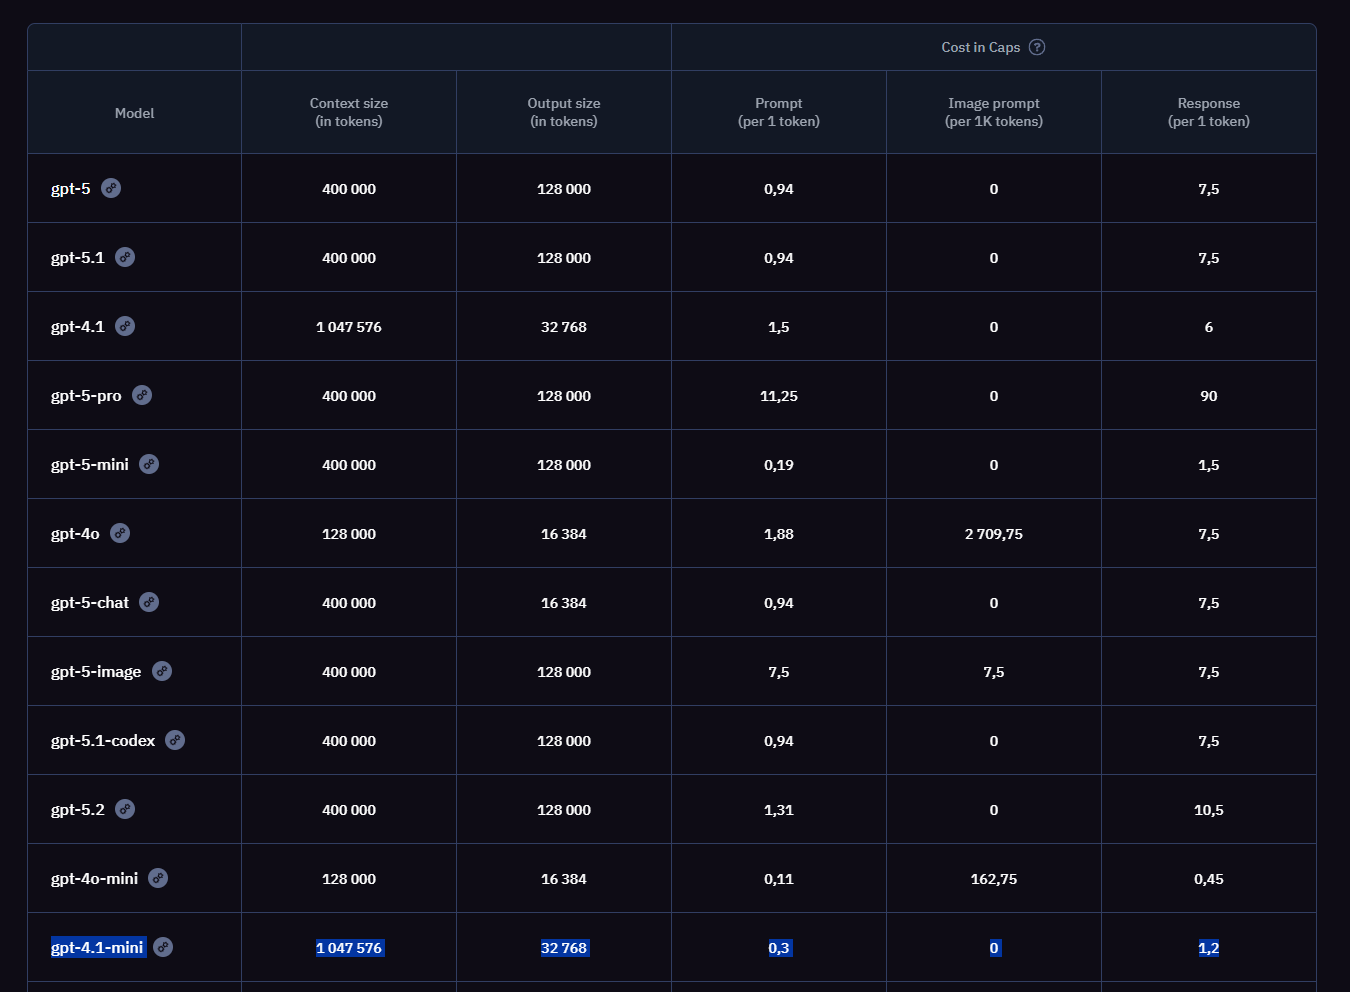

#HR

Let's try to simulate communication with an HR manager using AI.

In [ ]:
vacancy = 'Junior ml researcher'
required_skills = 'classic ml, python, sklearn'
pre_prompt = f"""
You are a recruiter for BEST_ML_COMPANY. You are attentive to details and empathetic.
It's important to you that the company and the candidate are a perfect match for each other. Your task is to understand whether a candidate is suitable for a vacancy: {vacancy} with key skills: {required_skills}.
As soon as the user gives his consent to receive the link and you understand that he is suitable, send him this: test_url_for_vacancy.
Introduce yourself, start texting, write about the company and who we need. Keep in mind that you have a maximum of 5 iterations to communicate with the user, after which communication will be impossible.
Write briefly and to the point. If you realize that the candidate is not suitable for you, type end before the rejection message. For example: end You are not suitable for us
"""
#Using pre_prompt, we set the context for the model so that it understands what it needs to do. It is worth noting that in the role we pass the system

In [ ]:
messages = 5
js = {'model': 'gpt-4.1-mini',
      'messages': [
        {'role': 'system', 'content': pre_prompt},
            ],
      'max_tokens': 1000}

for i in range(messages):
    print('--------------')
    user_mes = str(input())
    js['messages'].append({'role': 'user', 'content': user_mes})
    response = requests.post(
        'https://bothub.chat/api/v2/openai/v1/chat/completions',
        headers={
            'Authorization': f'Bearer {token}',
            'Content-Type': 'application/json',
        },
        json = js
        )
    result = response.json()
    js['messages'].append({'role': 'assistant', 'content': result['choices'][0]['message']['content']}) #Adding the model's response
    print('--------------')
    print("Model's response:", result['choices'][0]['message']['content'])
    if result['choices'][0]['message']['content'][0:3:] == 'end':
        break

--------------
hi
--------------
Model's response: Hello! I’m a recruiter at BEST_ML_COMPANY. We are looking for a Junior ML Researcher skilled in classic machine learning, Python, and sklearn. Could you tell me a bit about your experience with these?
--------------
I have no experience in ml, but I have in web application development.
--------------
Model's response: Thanks for sharing. Since this role specifically requires experience in classic ML, Python, and sklearn, web development alone might not be a match. Are you open to building skills in classic ML and Python?
--------------
No
--------------
Model's response: end Unfortunately, without experience or willingness to learn key skills in ML and Python, this role won’t be a good fit. I wish you the best in your job search!


This approach can also be used for chatbots to help navigate the site or services.

#Automatic note generation

By combining several models, you can create a "pipeline" for performing a variety of tasks. For example, below you can automatically record notes using your voice. If you connect this to a telegram bot, you can record a voice message directly to it, and it will return a to-do list for today.

In [ ]:
from openai import OpenAI

audio_file = open("audio_2025-12-16_12-47-05.ogg", "rb")

client = OpenAI(
  api_key=f'{token}',
  base_url='https://bothub.chat/api/v2/openai/v1'
)

transcript = client.audio.transcriptions.create(
  model="whisper-1",
  file=audio_file
)
text_note = transcript.text
print(f"Transcription: {text_note}")
prompt_transcription = f'''
Make a plan for the day, put everything in order of time and individual items. Write briefly, but clearly, do not add anything superfluous. That's what I want to see there: {text_note}
'''
response = requests.post(
    'https://bothub.chat/api/v2/openai/v1/chat/completions',
    headers={
        'Authorization': f'Bearer {token}',
        'Content-Type': 'application/json',
    },
    json={
        'model': 'gpt-4.1-mini',
        'messages': [
            {'role': 'user', 'content': prompt_transcription}
        ],
        'max_tokens': 1000,
    }
)

result = response.json()
print(result['choices'][0]['message']['content'])

text = result['choices'][0]['message']['content']
file_path = "plan.txt"

with open(file_path, "w", encoding="utf-8") as file:
    file.write(text)

Transcription: At about 10 a.m. I would like to start doing my homework. I was assigned at the university. Before that I need to have breakfast and do a little exercise. At the end of the day, at about 6 p.m., I have to have dinner and then meet a friend at 7 p.m. I also have lunch at 1 p.m. with my family.
- 8:00 a.m. – Breakfast  
- 8:30 a.m. – Exercise  
- 10:00 a.m. – Start homework  
- 1:00 p.m. – Lunch with family  
- 6:00 p.m. – Dinner  
- 7:00 p.m. – Meet friend


#Try prompt injection during the remaining workshop time
https://gandalf.lakera.ai/baseline